In [1]:
%pip install langchain_groq --q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model = 'llama-3.3-70b-versatile')


In [4]:
def extract_text(content):
    if isinstance(content, str):
        return content

    if isinstance(content, list):
        return "\n".join(
            item["text"]
            for item in content
            if item.get("type") == "text"
        )

    return str(content)

In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

## Graph State

class State(TypedDict):
    topic : str
    characters: str
    settings : str
    premises : str
    story_intro : str


## crate nodes
def generate_characters(state: State):
    message = llm.invoke(f"""Create 2 character names and breif traits for a story about {state["topic"]}.
""")
    return {"characters" : extract_text(message.content) }


def generate_settings(state: State):
    message = llm.invoke(f"""Describe the setting for a story about {state["topic"]}.
""")
    return {"settings" : extract_text(message.content) }


def generate_premises(state : State):
    message = llm.invoke(f"""Write a one sentence premise for a story about {state["topic"]}.
""")
    return {"premises" : extract_text(message.content)}


def combine_elements(state : State):
    message = llm.invoke(f"Write a short story about {state['topic']} using the following elements: \n"
    f"Characters: {state['characters']}\n"
    f"Settings: {state['settings']}\n"
    f"Premises: {state['premises']}\n"  )
    return {"story_intro" : extract_text(message.content)}

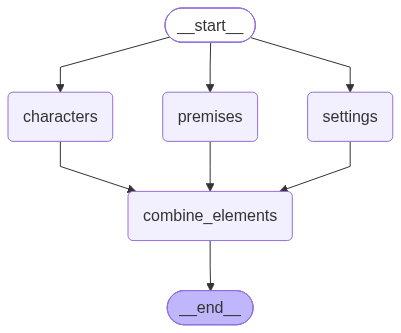

In [11]:

# build the state graph
graph = StateGraph(State)
graph.add_node("characters", generate_characters)
graph.add_node("settings", generate_settings)
graph.add_node("premises", generate_premises)
graph.add_node("combine_elements", combine_elements)
#define edges
graph.add_edge(START, "characters")
graph.add_edge(START, "settings")
graph.add_edge(START, "premises")
graph.add_edge("characters", "combine_elements")
graph.add_edge("settings", "combine_elements")
graph.add_edge("premises", "combine_elements")
graph.add_edge("combine_elements", END)

#compile the graph
compiled_graph = graph.compile()


#visualize the graph
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))


In [17]:
state = {"topic" : "Odyssey"}
result = compiled_graph.invoke(state)
print(result)

{'topic': 'Odyssey', 'characters': 'Here are two character names and brief traits for a story about Odyssey:\n\n1. **Kaelin "Kae" Darkhaven**: A skilled and resourceful young sailor with unparalleled knowledge of the sea. Kae is determined, brave, and has a strong sense of justice, which often leads her to take risks to protect her crew and the innocent.\n\n2. **Captain Thane Blackwood**: A seasoned and charismatic naval commander with a mysterious past. Thane is cunning, strategic, and has a reputation for being one of the most feared and respected captains on the high seas. Despite his tough exterior, he has a soft spot for those in need and is driven by a desire to uncover the truth about his family\'s cursed legacy.', 'settings': "The setting for a story about Odyssey is ancient Greece, specifically the Mediterranean region, during the Greek Dark Ages (circa 8th century BC). The story takes place in a world of city-states, kingdoms, and tribal territories, where myth and legend are

In [21]:
print("\n******* Topic ******")
print(result["topic"])

print("\n******* Characters ******")
print(result["characters"])



******* Topic ******
Odyssey

******* Characters ******
Here are two character names and brief traits for a story about Odyssey:

1. **Kaelin "Kae" Darkhaven**: A skilled and resourceful young sailor with unparalleled knowledge of the sea. Kae is determined, brave, and has a strong sense of justice, which often leads her to take risks to protect her crew and the innocent.

2. **Captain Thane Blackwood**: A seasoned and charismatic naval commander with a mysterious past. Thane is cunning, strategic, and has a reputation for being one of the most feared and respected captains on the high seas. Despite his tough exterior, he has a soft spot for those in need and is driven by a desire to uncover the truth about his family's cursed legacy.


In [22]:

print("\n******* Settings ******")
print(result["settings"])


******* Settings ******
The setting for a story about Odyssey is ancient Greece, specifically the Mediterranean region, during the Greek Dark Ages (circa 8th century BC). The story takes place in a world of city-states, kingdoms, and tribal territories, where myth and legend are intertwined with everyday life.

The narrative begins in Ithaca, a small island kingdom in the Ionian Sea, where the protagonist, Odysseus, rules as king. Ithaca is a rugged and mountainous island, with dense forests, rolling hills, and a scenic coastline. The kingdom is surrounded by the sea, with the mainland of Greece visible on the horizon.

As Odysseus embarks on his epic journey, the setting shifts to various locations throughout the Mediterranean, including:

1. The city of Troy, in northwest Anatolia (modern-day Turkey), where the Trojan War has just ended.
2. The island of Calypso, a mystical and idyllic paradise, where Odysseus is stranded for seven years.
3. The land of the Lotus-Eaters, a mythical 

In [20]:

print("\n******* Premises ******")
print(result["premises"])


******* Premises ******
As the last starship of a decimated fleet, the Odyssey embarks on a perilous journey through treacherous asteroid fields and hostile alien territories in search of a new home for humanity's surviving remnants.


In [19]:
print("\n*******Story Intro ******")
print(result["story_intro"])


*******Story Intro ******
What an intriguing combination of elements! Here's a short story that weaves together the characters, settings, and premises you provided:

In the ancient Greek world, Kaelin "Kae" Darkhaven, a skilled and resourceful young sailor, had heard tales of the legendary Odysseus and his epic journey. Growing up in the small island kingdom of Ithaca, Kae had always been fascinated by the stories of the sea and the mythical creatures that inhabited it. When she stumbled upon an ancient prophecy that spoke of a great odyssey to the stars, Kae knew she had to embark on a journey of her own.

As she set sail across the Mediterranean, Kae encountered Captain Thane Blackwood, a seasoned and charismatic naval commander with a mysterious past. Thane was on a mission to uncover the truth about his family's cursed legacy, and he saw Kae's determination and bravery as the perfect complement to his own cunning and strategic thinking.

Together, they formed an unlikely alliance,